### Adım 1.3 — İlk Keşif

In [1]:
import keras
keras.utils.set_random_seed(42)

In [2]:
import pandas as pd

df = pd.read_csv("C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\data\AEP_hourly.csv", parse_dates=["Datetime"])
df = df.sort_values("Datetime").reset_index(drop=True)
print(df.shape)
print(df["Datetime"].min(), df["Datetime"].max())
df.head()

(121273, 2)
2004-10-01 01:00:00 2018-08-03 00:00:00


,Datetime,AEP_MW
0,2004-10-01 01:00:00,12379.0
1,2004-10-01 02:00:00,11935.0
2,2004-10-01 03:00:00,11692.0
3,2004-10-01 04:00:00,11597.0
4,2004-10-01 05:00:00,11681.0


## Aşım anını saptama

In [3]:
# Her saat icin, "o anki talep" ile "onceki 30 gunun zirvesi" arasindaki orani hesapla
df_sorted = df.sort_values("Datetime").reset_index(drop=True)
df_sorted["trailing_30d_peak"] = df_sorted["AEP_MW"].rolling(window=24*30, min_periods=24*30).max().shift(1)
df_sorted["ratio_to_trailing_peak"] = df_sorted["AEP_MW"] / df_sorted["trailing_30d_peak"]

# En yuksek oranli (yani o anki talebin, kendi 30-gunluk gecmisine gore en "surpriz" oldugu) 5 an
en_surpriz = df_sorted.nlargest(5, "ratio_to_trailing_peak")[["Datetime", "AEP_MW", "trailing_30d_peak", "ratio_to_trailing_peak"]]
print(en_surpriz)

                 Datetime   AEP_MW  trailing_30d_peak  ratio_to_trailing_peak
35525 2008-10-20 14:00:00  25695.0            18544.0                1.385623
1768  2004-12-13 18:00:00  20103.0            18945.0                1.061124
45510 2009-12-10 18:00:00  21072.0            19896.0                1.059107
54172 2010-12-06 18:00:00  21715.0            20550.0                1.056691
97664 2015-11-23 07:00:00  17199.0            16328.0                1.053344


### Adım 2.1 — Zamana Göre Ayrım

In [4]:
split_date = df["Datetime"].max() - pd.Timedelta(days=30)
train_df = df[df["Datetime"] <= split_date].copy()
test_df = df[df["Datetime"] > split_date].copy()
print(f"Train: up to {train_df['Datetime'].max()} | Test: {test_df['Datetime'].min()} to {test_df['Datetime'].max()}")

Train: up to 2018-07-04 00:00:00 | Test: 2018-07-04 01:00:00 to 2018-08-03 00:00:00


### Adım 2.2 — Basit Baseline (Bir Önceki Gün Aynı Saat)

In [5]:
import numpy as np

def rmspe(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = np.abs(y_true) > 1e-6
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))

# Baseline: same hour, 24 hours ago
baseline_pred = df["AEP_MW"].shift(24)
test_mask = df["Datetime"] > split_date
baseline_rmspe = rmspe(df.loc[test_mask, "AEP_MW"], baseline_pred[test_mask])
print("Baseline RMSPE:", baseline_rmspe)

Baseline RMSPE: 0.0837647270056018


### Adım 2.3 — Veri Hazırlama (Pencereleme)

In [6]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress harmless TensorFlow GPU warnings

from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler
from pandas.tseries.holiday import USFederalHolidayCalendar

In [7]:
import requests
from dotenv import load_dotenv
load_dotenv(r"C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\notepads\.env")
NOAA_TOKEN = os.getenv("NOAA_TOKEN")
headers = {"token": NOAA_TOKEN}

Adım A — Doğru İstasyonu Bulun

In [8]:
response = requests.get(
    "https://www.ncei.noaa.gov/cdo-web/api/v2/stations",
    headers=headers,
    params={
        "extent": "39.7,-83.3,40.2,-82.7",
        "datasetid": "GHCND",
        "startdate": "2004-10-01",
        "enddate": "2018-08-03",
        "sortfield": "datacoverage",
        "sortorder": "desc",   # prioritize the most complete data among stations covering our date range
        "limit": 20,
    }
)
print(response.json())

{'metadata': {'resultset': {'offset': 1, 'count': 47, 'limit': 20}}, 'results': [{'elevation': 232.3, 'mindate': '2016-08-28', 'maxdate': '2016-12-05', 'latitude': 39.994647, 'name': 'COLUMBUS 1.4 WNW, OH US', 'datacoverage': 1, 'id': 'GHCND:US1OHFR0048', 'elevationUnit': 'METERS', 'longitude': -83.013145}, {'elevation': 314.6, 'mindate': '2009-03-29', 'maxdate': '2026-09-24', 'latitude': 40.04029, 'name': 'NEW ALBANY 2.8 SSE, OH US', 'datacoverage': 1, 'id': 'GHCND:US1OHFR0008', 'elevationUnit': 'METERS', 'longitude': -82.798033}, {'elevation': 234.1, 'mindate': '2009-02-01', 'maxdate': '2026-09-24', 'latitude': 39.980958, 'name': 'GRANDVIEW HEIGHTS 0.1 N, OH US', 'datacoverage': 0.9994, 'id': 'GHCND:US1OHFR0003', 'elevationUnit': 'METERS', 'longitude': -83.040056}, {'elevation': 294.1, 'mindate': '2014-07-08', 'maxdate': '2018-08-06', 'latitude': 40.16415, 'name': 'DUBLIN 3.7 NNW, OH US', 'datacoverage': 0.998, 'id': 'GHCND:US1OHDL0008', 'elevationUnit': 'METERS', 'longitude': -83.16

Adım B — Günlük Sıcaklığı Çekin (Sayfalama Dahil)

In [9]:
import pandas as pd
import requests
import time

def fetch_ghcnd(station_id, overall_start, overall_end, token):
    """
    Fetches daily NOAA GHCND temperature data.
    - Splits the date range into 364-day chunks to comply with the
      API's "must be less than 1 year" rule.
    - Paginates within each chunk using offset, to handle the API's
      1000-row page limit.
    """
    all_results = []
    current_start = pd.Timestamp(overall_start)
    final_end = pd.Timestamp(overall_end)

    while current_start <= final_end:
        current_end = min(current_start + pd.Timedelta(days=364), final_end)
        print(f"Fetching: {current_start.date()} - {current_end.date()}")

        offset = 1
        while True:
            r = requests.get(
                "https://www.ncei.noaa.gov/cdo-web/api/v2/data",
                headers={"token": token},
                params={
                    "datasetid": "GHCND", "stationid": station_id,
                    "startdate": str(current_start.date()),
                    "enddate": str(current_end.date()),
                    "datatypeid": ["TMAX", "TMIN"],
                    "units": "standard",
                    "limit": 1000, "offset": offset,
                },
            )
            if r.status_code != 200:
                print(f"  ERROR: HTTP {r.status_code} - {r.text[:300]}")
                break

            page_data = r.json().get("results", [])
            if not page_data:
                break

            all_results.extend(page_data)
            offset += 1000
            time.sleep(0.25)  # respect NOAA's 5 requests/sec limit

        current_start = current_end + pd.Timedelta(days=1)

    return pd.DataFrame(all_results)


weather_df = fetch_ghcnd("GHCND:USW00004804", "2004-10-01", "2018-08-03", NOAA_TOKEN)

Fetching: 2004-10-01 - 2005-09-30
Fetching: 2005-10-01 - 2006-09-30
Fetching: 2006-10-01 - 2007-09-30
Fetching: 2007-10-01 - 2008-09-29
Fetching: 2008-09-30 - 2009-09-29
Fetching: 2009-09-30 - 2010-09-29
Fetching: 2010-09-30 - 2011-09-29
Fetching: 2011-09-30 - 2012-09-28
Fetching: 2012-09-29 - 2013-09-28
Fetching: 2013-09-29 - 2014-09-28
Fetching: 2014-09-29 - 2015-09-28
Fetching: 2015-09-29 - 2016-09-27
Fetching: 2016-09-28 - 2017-09-27
Fetching: 2017-09-28 - 2018-08-03


In [10]:
weather_df.shape

(10087, 5)

Adım C — HDD/CDD Hesaplayıp Ana Veriyle Birleştirin

In [11]:
df["hour"] = df["Datetime"].dt.hour
df["day_of_week"] = df["Datetime"].dt.dayofweek
df["month"] = df["Datetime"].dt.month
df["is_weekend"] = df["Datetime"].dt.dayofweek >= 5

calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=df["Datetime"].min(), end=df["Datetime"].max())
df["is_holiday"] = df["Datetime"].dt.normalize().isin(holidays)

weather_pivot = weather_df.pivot_table(index="date", columns="datatype", values="value").reset_index()
weather_pivot["date"] = pd.to_datetime(weather_pivot["date"]).dt.date
weather_pivot["avg_temp_f"] = (weather_pivot["TMAX"] + weather_pivot["TMIN"]) / 2
weather_pivot["HDD"] = (65 - weather_pivot["avg_temp_f"]).clip(lower=0)
weather_pivot["CDD"] = (weather_pivot["avg_temp_f"] - 65).clip(lower=0)

df["date_only"] = df["Datetime"].dt.date
df = df.merge(weather_pivot[["date", "avg_temp_f", "HDD", "CDD"]], left_on="date_only", right_on="date", how="left")
df["avg_temp_f"] = df["avg_temp_f"].ffill().bfill()
df["HDD"] = df["HDD"].ffill().bfill()
df["CDD"] = df["CDD"].ffill().bfill()

features = ["AEP_MW", "hour", "day_of_week", "month", "is_weekend", "is_holiday", "avg_temp_f", "HDD", "CDD"]
data = df[features].astype(float).values

split_index = train_df.shape[0]
train_data = data[:split_index]
test_data = data[split_index:]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

window_size = 24
n_features = len(features)

def split_window(window):
    X = window[:, :window_size, :]
    y = window[:, window_size, 0]
    return X, y

train_ds = keras.utils.timeseries_dataset_from_array(
    data=train_scaled, targets=None,
    sequence_length=window_size + 1, batch_size=32,
    shuffle=True, seed=42
).map(split_window)

test_ds = keras.utils.timeseries_dataset_from_array(
    data=test_scaled, targets=None,
    sequence_length=window_size + 1, batch_size=32
).map(split_window)

print(f"window_size={window_size}, n_features={n_features}")
print("Kullanilan ozellikler:", features)

df.to_csv(r"C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\data\aep_with_features.csv", index=False)

window_size=24, n_features=9
Kullanilan ozellikler: ['AEP_MW', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_holiday', 'avg_temp_f', 'HDD', 'CDD']


In [12]:
real_last_24 = test_data[-24:].tolist()
print(real_last_24)

[[13286.0, 1.0, 3.0, 8.0, 0.0, 0.0, 73.5, 0.0, 8.5], [12587.0, 2.0, 3.0, 8.0, 0.0, 0.0, 73.5, 0.0, 8.5], [12296.0, 3.0, 3.0, 8.0, 0.0, 0.0, 73.5, 0.0, 8.5], [12059.0, 4.0, 3.0, 8.0, 0.0, 0.0, 73.5, 0.0, 8.5], [12224.0, 5.0, 3.0, 8.0, 0.0, 0.0, 73.5, 0.0, 8.5], [12781.0, 6.0, 3.0, 8.0, 0.0, 0.0, 73.5, 0.0, 8.5], [13661.0, 7.0, 3.0, 8.0, 0.0, 0.0, 73.5, 0.0, 8.5], [14326.0, 8.0, 3.0, 8.0, 0.0, 0.0, 73.5, 0.0, 8.5], [14834.0, 9.0, 3.0, 8.0, 0.0, 0.0, 73.5, 0.0, 8.5], [15309.0, 10.0, 3.0, 8.0, 0.0, 0.0, 73.5, 0.0, 8.5], [16025.0, 11.0, 3.0, 8.0, 0.0, 0.0, 73.5, 0.0, 8.5], [16651.0, 12.0, 3.0, 8.0, 0.0, 0.0, 73.5, 0.0, 8.5], [17423.0, 13.0, 3.0, 8.0, 0.0, 0.0, 73.5, 0.0, 8.5], [18067.0, 14.0, 3.0, 8.0, 0.0, 0.0, 73.5, 0.0, 8.5], [18534.0, 15.0, 3.0, 8.0, 0.0, 0.0, 73.5, 0.0, 8.5], [18826.0, 16.0, 3.0, 8.0, 0.0, 0.0, 73.5, 0.0, 8.5], [18869.0, 17.0, 3.0, 8.0, 0.0, 0.0, 73.5, 0.0, 8.5], [18562.0, 18.0, 3.0, 8.0, 0.0, 0.0, 73.5, 0.0, 8.5], [18118.0, 19.0, 3.0, 8.0, 0.0, 0.0, 73.5, 0.0, 8.5], [

### Adım 2.4 — LSTM Modelini Kurun ve Eğitin

In [13]:
model = keras.Sequential([
    keras.layers.Input(shape=(window_size, n_features)),
    keras.layers.LSTM(64, return_sequences=True),
    keras.layers.LSTM(32),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(1)
])
model.compile(optimizer="adam", loss="mae")
model.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=8, restore_best_weights=True
)

history = model.fit(
    train_ds, validation_data=test_ds, epochs=20,
    callbacks=[early_stop]
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,905 (124.63 KB)

 Trainable params: 31,905 (124.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20


c:\Anaconda\envs\bitirme-proje\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


3767/3767 ━━━━━━━━━━━━━━━━━━━━ 64s 16ms/step - loss: 0.0203 - val_loss: 0.0082
Epoch 2/20
3767/3767 ━━━━━━━━━━━━━━━━━━━━ 61s 16ms/step - loss: 0.0101 - val_loss: 0.0071
Epoch 3/20
3767/3767 ━━━━━━━━━━━━━━━━━━━━ 58s 15ms/step - loss: 0.0093 - val_loss: 0.0074
Epoch 4/20
3767/3767 ━━━━━━━━━━━━━━━━━━━━ 57s 15ms/step - loss: 0.0086 - val_loss: 0.0075
Epoch 5/20
3767/3767 ━━━━━━━━━━━━━━━━━━━━ 61s 16ms/step - loss: 0.0081 - val_loss: 0.0072
Epoch 6/20
3767/3767 ━━━━━━━━━━━━━━━━━━━━ 62s 16ms/step - loss: 0.0079 - val_loss: 0.0071
Epoch 7/20
3767/3767 ━━━━━━━━━━━━━━━━━━━━ 57s 15ms/step - loss: 0.0077 - val_loss: 0.0090
Epoch 8/20
3767/3767 ━━━━━━━━━━━━━━━━━━━━ 62s 16ms/step - loss: 0.0075 - val_loss: 0.0064
Epoch 9/20
3767/3767 ━━━━━━━━━━━━━━━━━━━━ 59s 16ms/step - loss: 0.0074 - val_loss: 0.0070
Epoch 10/20
3767/3767 ━━━━━━━━━━━━━━━━━━━━ 89s 17ms/step - loss: 0.0072 - val_loss: 0.0063
Epoch 11/20
3767/3767 ━━━━━━━━━━━━━━━━━━━━ 88s 19ms/step - loss: 0.0071 - val_loss: 0.0084
Epoch 12/20
3767/37

## Model Kaydetme

In [14]:
import joblib

model.save(r"C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\agent\grid_model.keras")
joblib.dump(scaler, r"C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\agent\grid_scaler.pkl")

print("Model and scaler saved.")

Model and scaler saved.


### Adım 2.5 — Overfitting Kontrolü 

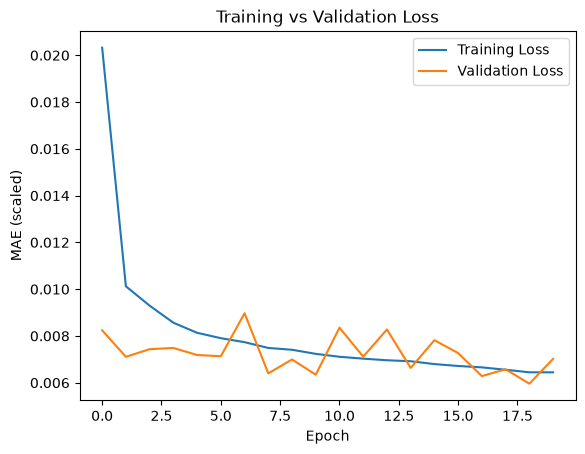

In [15]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MAE (scaled)")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

### Adım 2.6 — Hata Analizi (Sıfıra Bölme Koruması)

In [16]:
predictions = model.predict(test_ds).flatten()
actuals = np.concatenate([y for _, y in test_ds], axis=0)

test_results = df[df["Datetime"] > split_date].iloc[window_size:].copy()
test_results["pred_scaled"] = predictions
test_results["actual_scaled"] = actuals

# Zero-division protection (learned from the Rossmann project)
valid_mask = np.abs(test_results["actual_scaled"]) > 1e-6
error_pct = (test_results.loc[valid_mask, "actual_scaled"] - test_results.loc[valid_mask, "pred_scaled"]) / test_results.loc[valid_mask, "actual_scaled"]
lstm_rmspe = np.sqrt(np.mean(error_pct ** 2))

print(f"Valid rows: {valid_mask.sum()} / {len(test_results)}")
print("LSTM RMSPE:", lstm_rmspe)
print("vs Baseline:", "better" if lstm_rmspe < baseline_rmspe else "worse or equal")

test_results["error_pct"] = np.nan
test_results.loc[valid_mask, "error_pct"] = error_pct
print(test_results.groupby("hour")["error_pct"].apply(lambda x: x.abs().mean()))

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Valid rows: 696 / 696
LSTM RMSPE: 0.027334567483591043
vs Baseline: better
hour
0     0.017167
1     0.020527
2     0.023946
3     0.021537
4     0.026778
5     0.031106
6     0.030083
7     0.046457
8     0.029855
9     0.020812
10    0.021465
11    0.012857
12    0.012558
13    0.012403
14    0.012215
15    0.009819
16    0.011907
17    0.010406
18    0.012198
19    0.014781
20    0.014844
21    0.015744
22    0.022524
23    0.013766
Name: error_pct, dtype: float64


## 

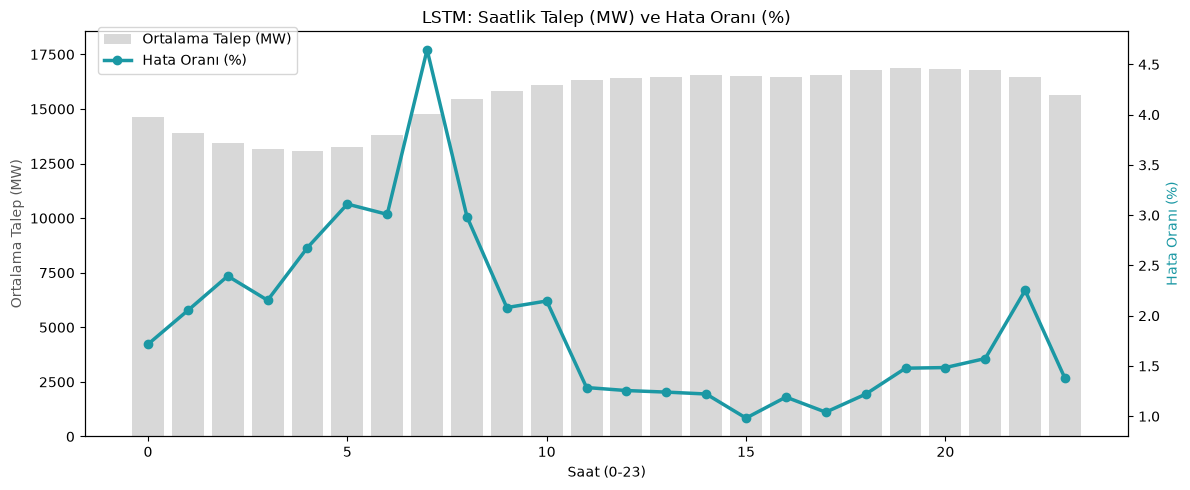

In [17]:
hourly_error_analysis = test_results.groupby("hour")["error_pct"].apply(lambda x: x.abs().mean())
import matplotlib.pyplot as plt

hourly_mw = df.groupby("hour")["AEP_MW"].mean().sort_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(hourly_mw.index, hourly_mw.values, color="#CFCFCF", alpha=0.8, label="Ortalama Talep (MW)")
ax1.set_xlabel("Saat (0-23)")
ax1.set_ylabel("Ortalama Talep (MW)", color="#595959")
ax1.set_ylim(0, hourly_mw.max() * 1.1)

ax2 = ax1.twinx()
ax2.plot(hourly_error_analysis.index, hourly_error_analysis.values * 100, color="#1B98A4", linewidth=2.5, marker="o", label="Hata Oranı (%)")
ax2.set_ylabel("Hata Oranı (%)", color="#1B98A4")

ax1.set_title("LSTM: Saatlik Talep (MW) ve Hata Oranı (%)")
fig.legend(loc="upper left", bbox_to_anchor=(0.08, 0.95))
plt.tight_layout()
plt.savefig(r"C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\graphs\viz_lstm_mw_vs_error.png", dpi=150)
plt.show()

Adım D

In [18]:
import os

metrics_dir = r"C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\metrics"
os.makedirs(metrics_dir, exist_ok=True)

# 1) Real sample windows for API testing (unscaled, raw data)
last_24h = pd.DataFrame(test_data[-24:], columns=features)
last_24h.to_csv(os.path.join(metrics_dir, "api_test_last_24h.csv"), index=False)

last_30_days = pd.DataFrame(test_data[-24*30:], columns=features)
last_30_days.to_csv(os.path.join(metrics_dir, "api_test_last_30_days.csv"), index=False)

# 2) Monthly summary for the full period (2004-2018)
df["year_month"] = df["Datetime"].dt.to_period("M")
monthly_summary = df.groupby("year_month").agg(
    avg_mw=("AEP_MW", "mean"),
    max_mw=("AEP_MW", "max"),
    min_mw=("AEP_MW", "min"),
    avg_temp_f_mean=("avg_temp_f", "mean"),
    total_hdd=("HDD", "sum"),
    total_cdd=("CDD", "sum"),
).reset_index()
monthly_summary["year_month"] = monthly_summary["year_month"].astype(str)
monthly_summary.to_csv(os.path.join(metrics_dir, "monthly_summary_full_period.csv"), index=False)

# 3) Model performance metrics (baseline vs LSTM)
model_metrics = pd.DataFrame({
    "metric": ["baseline_rmspe", "lstm_rmspe"],
    "value": [baseline_rmspe, lstm_rmspe]
})
model_metrics.to_csv(os.path.join(metrics_dir, "model_metrics.csv"), index=False)

# 4) Hourly error analysis (permanent record of the Step 2.6 finding)
hourly_error = test_results.groupby("hour")["error_pct"].apply(lambda x: x.abs().mean())
hourly_error.to_csv(os.path.join(metrics_dir, "hourly_error_analysis.csv"))

print("All metrics saved to:", metrics_dir)
print(monthly_summary.tail())

All metrics saved to: C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\metrics
    year_month        avg_mw   max_mw   min_mw  avg_temp_f_mean  total_hdd  \
162    2018-04  13639.244444  17507.0   9815.0        46.100000    13716.0   
163    2018-05  14117.005376  20581.0   9925.0        70.000000      444.0   
164    2018-06  15305.250000  22253.0  10863.0        72.850000      288.0   
165    2018-07  15926.622312  21481.0  10343.0        74.241935        0.0   
166    2018-08  15406.959184  18869.0  12059.0        71.816327        0.0   

     total_cdd  
162      108.0  
163     4164.0  
164     5940.0  
165     6876.0  
166      334.0  


## Gmail Draft için Aşım Anı

In [19]:
import joblib
from tensorflow import keras

# 1) Kaydedilmis model ve scaler'i yukle (tekrar egitim gereksiz)
hist_model = keras.models.load_model(r"C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\agent\grid_model.keras")
hist_scaler = joblib.load(r"C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\agent\grid_scaler.pkl")

# 2) Hedef ani bul (2008-10-20 14:00) ve onceki 24 saati al
# Not: df hucre 16'da tanimlandi, features hucre 15 civarinda tanimlandi
target_dt = pd.Timestamp("2008-10-20 14:00:00")
target_idx = df[df["Datetime"] == target_dt].index[0]
window_raw = df.iloc[target_idx-24:target_idx][features].values

# 3) Olcekle, tahmin yap, geri donustur
window_scaled = hist_scaler.transform(window_raw)
hist_pred_scaled = hist_model.predict(window_scaled.reshape(1, 24, len(features))).flatten()[0]
dummy_row = np.zeros((1, len(features)))
dummy_row[0, 0] = hist_pred_scaled
hist_forecast_mw = hist_scaler.inverse_transform(dummy_row)[0, 0]

# 4) O ana kadar olan 30 gunluk trailing peak ile kapasiteyi hesapla
trailing_30d_peak = df.iloc[target_idx-24*30:target_idx]["AEP_MW"].max()
hist_capacity = round(trailing_30d_peak * 1.20)
hist_time_period = "day"  # saat 14:00

marj = (1 - hist_forecast_mw / hist_capacity) * 100
print(f"Tarihi tahmin : {hist_forecast_mw:.0f} MW")
print(f"Kapasite      : {hist_capacity} MW  (trailing 30d peak {trailing_30d_peak:.0f} x 1.20)")
print(f"Gercek marj   : %{marj:.1f}")
print(f"Zaman dilimi  : {hist_time_period}")
print("features degiskeni:", features)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
Tarihi tahmin : 16110 MW
Kapasite      : 22253 MW  (trailing 30d peak 18544 x 1.20)
Gercek marj   : %27.6
Zaman dilimi  : day
features degiskeni: ['AEP_MW', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_holiday', 'avg_temp_f', 'HDD', 'CDD']


## Tüm zamanlar Trend

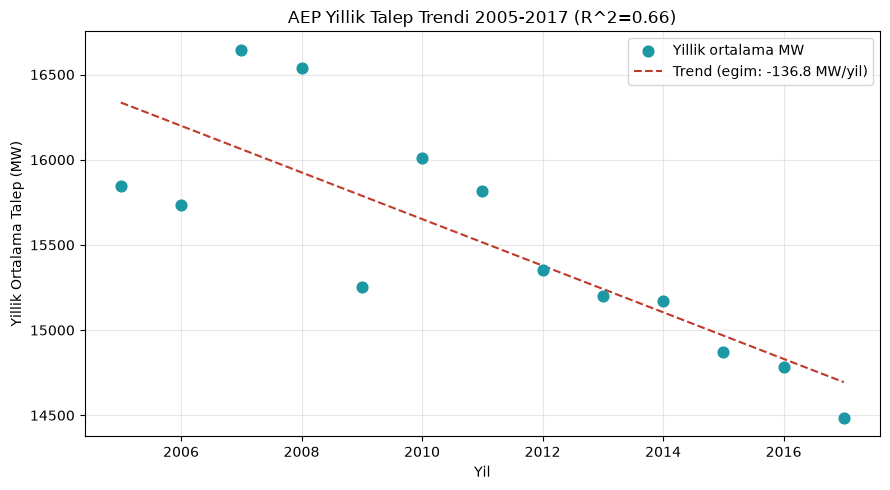

Egim: -136.80 MW/yil, R^2: 0.6624
2005->2017 toplam degisim: %-10.4


In [20]:
import os
import matplotlib.pyplot as plt
import numpy as np

trend_dir = r"C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\graphs\trend"
os.makedirs(trend_dir, exist_ok=True)

df["year"] = df["Datetime"].dt.year
tam_yillar = df[(df["year"] >= 2005) & (df["year"] <= 2017)]
yillik_ort = tam_yillar.groupby("year")["AEP_MW"].mean()

years = yillik_ort.index.values
values = yillik_ort.values
slope, intercept = np.polyfit(years, values, 1)
r2 = np.corrcoef(years, values)[0, 1] ** 2

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(years, values, color="#1B98A4", s=60, zorder=3, label="Yillik ortalama MW")
trend_line = slope * years + intercept
ax.plot(years, trend_line, color="#C0392B", linestyle="--", label=f"Trend (egim: {slope:.1f} MW/yil)")
ax.set_xlabel("Yil")
ax.set_ylabel("Yillik Ortalama Talep (MW)")
ax.set_title(f"AEP Yillik Talep Trendi 2005-2017 (R^2={r2:.2f})")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{trend_dir}\\annual_demand_trend.png", dpi=150)
plt.show()

print(f"Egim: {slope:.2f} MW/yil, R^2: {r2:.4f}")
print(f"2005->2017 toplam degisim: %{(slope*12/values[0]*100):.1f}")

## Aylık Trend

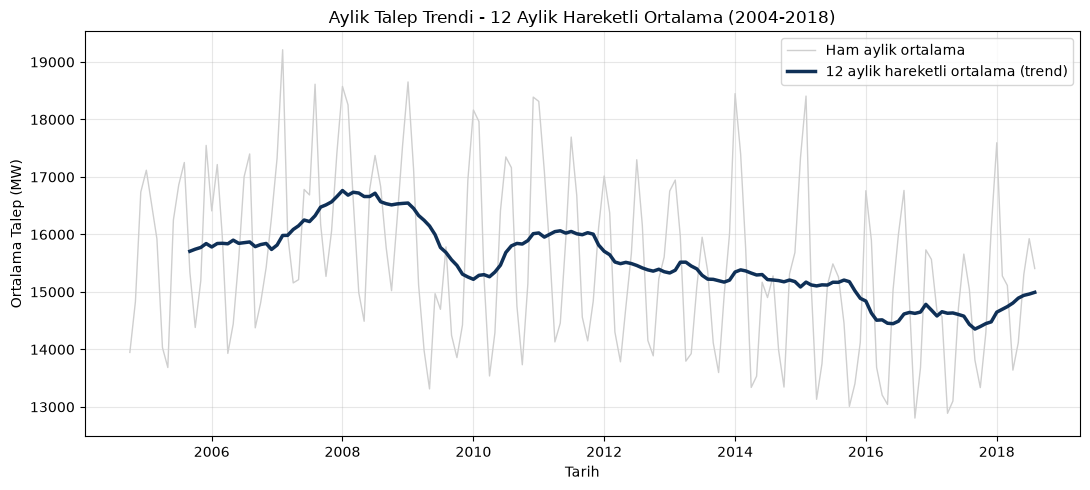

In [21]:
monthly = pd.read_csv(r"C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\metrics\monthly_summary_full_period.csv")
monthly["year_month"] = pd.to_datetime(monthly["year_month"])
monthly = monthly.sort_values("year_month").reset_index(drop=True)

monthly["rolling_12ay"] = monthly["avg_mw"].rolling(window=12, min_periods=12).mean()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly["year_month"], monthly["avg_mw"], color="#CFCFCF", linewidth=1, label="Ham aylik ortalama")
ax.plot(monthly["year_month"], monthly["rolling_12ay"], color="#0F3057", linewidth=2.5, label="12 aylik hareketli ortalama (trend)")
ax.set_xlabel("Tarih")
ax.set_ylabel("Ortalama Talep (MW)")
ax.set_title("Aylik Talep Trendi - 12 Aylik Hareketli Ortalama (2004-2018)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(r"C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\graphs\trend\monthly_rolling_trend.png", dpi=150)
plt.show()

In [22]:
import calendar

yearly_dir = r"C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\graphs\trend\Yearly"

for year in range(2005, 2017):  # 2005-2016 = 12 tam yil
    for month_num in range(1, 13):
        month_name = calendar.month_name[month_num]
        month_dir = f"{yearly_dir}\\{year}\\{month_name}"
        os.makedirs(month_dir, exist_ok=True)

        month_data = df[(df["Datetime"].dt.year == year) & (df["Datetime"].dt.month == month_num)]
        if month_data.empty:
            continue

        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(month_data["Datetime"], month_data["AEP_MW"], color="#1B98A4", linewidth=0.8)
        ax.set_title(f"AEP Saatlik Talep - {month_name} {year}")
        ax.set_xlabel("Tarih")
        ax.set_ylabel("MW")
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"{month_dir}\\hourly_demand.png", dpi=100)
        plt.close(fig)  # bellek tasmasini onlemek icin kapatiyoruz

    print(f"{year} tamamlandi")

print("\nToplam 144 grafik olusturuldu:", yearly_dir)

2005 tamamlandi
2006 tamamlandi
2007 tamamlandi
2008 tamamlandi
2009 tamamlandi
2010 tamamlandi
2011 tamamlandi
2012 tamamlandi
2013 tamamlandi
2014 tamamlandi
2015 tamamlandi
2016 tamamlandi

Toplam 144 grafik olusturuldu: C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\graphs\trend\Yearly


## FAZ 5 — Uçtan Uca Entegrasyon

In [23]:
import sys, os, json, requests
sys.path.append(r"C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\notepads")
from rag_retrieval import retrieve_context, build_rag_query
from google import genai
from google.genai import types
from google.genai import errors
from dotenv import load_dotenv
from langsmith import traceable
from prompt_v1 import SYSTEM_PROMPT

load_dotenv(r"C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\notepads\.env")
client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))

# 1) Generate forecast using the REAL last 24 hours of test data
new_data = test_scaled[-window_size:].reshape(1, window_size, n_features)
pred_scaled = model.predict(new_data).flatten()[0]

dummy_row = np.zeros((1, n_features))
dummy_row[0, 0] = pred_scaled
forecast_mw = scaler.inverse_transform(dummy_row)[0, 0]

confidence_margin = forecast_mw * lstm_rmspe
confidence_interval = [round(forecast_mw - confidence_margin), round(forecast_mw + confidence_margin)]

# 2) SIMULATED grid capacity, anchored to PJM's official 20% IRM
np.random.seed(42)
recent_peak_mw = df["AEP_MW"].tail(24*30).max()
irm_margin = 0.20
available_capacity_mw = round(recent_peak_mw * (1 + irm_margin) * np.random.uniform(0.97, 1.03))

last_hour = df["Datetime"].iloc[-1].hour
if 7 <= last_hour < 18:
    time_period = "day"
elif 18 <= last_hour < 23:
    time_period = "peak"
else:
    time_period = "night"

demand_forecast = {"region": "AEP", "forecast_mw": round(forecast_mw), "confidence_interval": confidence_interval}
grid_status = {
    "available_capacity_mw": available_capacity_mw,
    "time_period": time_period,
    "capacity_source": "simulated_from_PJM_2027-2028_IRM_20pct"
}

# 3) RAG: retrieve real PJM procedure context (single call)
rag_query = build_rag_query(forecast_mw, available_capacity_mw, time_period)
retrieved_context = retrieve_context(rag_query)

content = f"""<demand_forecast>
{json.dumps(demand_forecast)}
</demand_forecast>
<grid_status>
{json.dumps(grid_status)}
</grid_status>
<official_procedure_context>
{retrieved_context}
</official_procedure_context>"""

print("Real input data:", demand_forecast, grid_status)

# 4) Agent call (single call, RAG-enriched, traceable)
@traceable(name="grid_agent_decision_with_rag")
def get_agent_decision(content, system_prompt):
    response = client.models.generate_content(
        model="gemini-3.7-flash", contents=content,
        config=types.GenerateContentConfig(
            system_instruction=system_prompt, temperature=0.2,
            response_mime_type="application/json",
        ),
    )
    return response.text

decision_json = None
try:
    result_text = get_agent_decision(content, SYSTEM_PROMPT)
    decision_json = json.loads(result_text)
    decision_json["region"] = "AEP"
    print("Agent decision:", decision_json)
except errors.ClientError as e:
    if "RESOURCE_EXHAUSTED" in str(e) or "429" in str(e):
        print("STOPPED: Gemini API quota exceeded. Nothing sent to n8n.")
    else:
        raise

# 5) Send to n8n (single call, only if a decision exists)
if decision_json is not None:
    result = requests.post("http://localhost:5678/webhook/grid-forecast", json=decision_json)
    print(result.status_code, result.text)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Real input data: {'region': 'AEP', 'forecast_mw': 13791, 'confidence_interval': [13414, 14168]} {'available_capacity_mw': 25570, 'time_period': 'night', 'capacity_source': 'simulated_from_PJM_2027-2028_IRM_20pct'}
Agent decision: {'reasoning_steps': 'Forecasted demand of 13,791 MW (upper confidence bound 14,168 MW) is well below the available capacity of 25,570 MW during the off-peak night period. With an extensive capacity cushion, operating and contingency reserves remain fully covered.', 'status': 'normal', 'decision': 'normal_operation', 'justification': 'Forecasted demand is comfortably within total capacity, satisfying all primary and operating reserve requirements under PJM Manual 11 guidelines for normal operations.', 'uncertainty': 'low', 'confidence_note': 'Data provided is complete and consistent across demand forecast and grid status; no assumptions were required.', 'region': 'AEP'}
200 {"message":"Workflow was started"}


### Hücre 1: Model ve scaler'ı yükle

In [24]:
import joblib
from tensorflow import keras

hist_model = keras.models.load_model(r"C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\agent\grid_model.keras")
hist_scaler = joblib.load(r"C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\agent\grid_scaler.pkl")

# Kayit icin: 2008-10-20 14:00 tek saatlik veri anomalisi
anom_idx = df[df["Datetime"] == pd.Timestamp("2008-10-20 14:00:00")].index[0]
print(df.iloc[anom_idx-4:anom_idx+5][["Datetime", "AEP_MW"]])

                 Datetime   AEP_MW
35521 2008-10-20 10:00:00  17488.0
35522 2008-10-20 11:00:00  17070.0
35523 2008-10-20 12:00:00  16640.0
35524 2008-10-20 13:00:00  16353.0
35525 2008-10-20 14:00:00  25695.0
35526 2008-10-20 15:00:00  15991.0
35527 2008-10-20 16:00:00  15687.0
35528 2008-10-20 17:00:00  15662.0
35529 2008-10-20 18:00:00  15634.0


### Hücre 2: tarihi_senaryo fonksiyonu (önceki mesajdaki ile aynı)

In [25]:
def tarihi_senaryo(target_str, send=False):
    target_dt = pd.Timestamp(target_str)
    idx = df[df["Datetime"] == target_dt].index[0]

    # 1) Komsu saatler: anomali mi, gercek zirve mi?
    print(df.iloc[idx-3:idx+4][["Datetime", "AEP_MW"]])

    # 2) Onceki 24 saatle GERCEK model tahmini
    window_scaled = hist_scaler.transform(df.iloc[idx-24:idx][features].values)
    pred_scaled = hist_model.predict(window_scaled.reshape(1, 24, len(features)), verbose=0).flatten()[0]
    dummy = np.zeros((1, len(features)))
    dummy[0, 0] = pred_scaled
    f_mw = hist_scaler.inverse_transform(dummy)[0, 0]

    # 3) Formul kapasitesi ve zaman dilimi
    cap = round(df.iloc[idx-24*30:idx]["AEP_MW"].max() * 1.20)
    h = target_dt.hour
    tp = "day" if 7 <= h < 18 else ("peak" if 18 <= h < 23 else "night")
    actual = df.loc[idx, "AEP_MW"]
    print(f"Gercek: {actual:.0f} | Tahmin: {f_mw:.0f} | Kapasite: {cap} | "
          f"Tahmin marji: %{(1 - f_mw/cap)*100:.1f} | Donem: {tp}")

    if not send:
        return

    # 4) Faz 5 ile ayni zincir (model TAHMINI ile)
    ci = f_mw * lstm_rmspe
    demand_forecast = {"region": "AEP", "forecast_mw": round(f_mw),
                       "confidence_interval": [round(f_mw - ci), round(f_mw + ci)]}
    grid_status = {"available_capacity_mw": cap, "time_period": tp,
                   "capacity_source": f"historical_{target_str}_trailing30d_x1.20"}
    rag_query = build_rag_query(f_mw, cap, tp)
    retrieved_context = retrieve_context(rag_query)
    content = f"""<demand_forecast>
{json.dumps(demand_forecast)}
</demand_forecast>
<grid_status>
{json.dumps(grid_status)}
</grid_status>
<official_procedure_context>
{retrieved_context}
</official_procedure_context>"""
    decision_json = json.loads(get_agent_decision(content, SYSTEM_PROMPT))
    decision_json["region"] = "AEP"
    print("RAG sorgusu:", rag_query)
    print("Agent karari:", decision_json)
    result = requests.post("http://localhost:5678/webhook/grid-forecast", json=decision_json)
    print(result.status_code, result.text)

for t in ["2004-12-13 18:00:00", "2009-12-10 18:00:00", "2010-12-06 18:00:00", "2015-11-23 07:00:00"]:
    tarihi_senaryo(t)
    print("-" * 60)

                Datetime   AEP_MW
1765 2004-12-13 15:00:00  18438.0
1766 2004-12-13 16:00:00  18484.0
1767 2004-12-13 17:00:00  18945.0
1768 2004-12-13 18:00:00  20103.0
1769 2004-12-13 19:00:00  20564.0
1770 2004-12-13 20:00:00  20447.0
1771 2004-12-13 21:00:00  20311.0
Gercek: 20103 | Tahmin: 20002 | Kapasite: 22734 | Tahmin marji: %12.0 | Donem: peak
------------------------------------------------------------
                 Datetime   AEP_MW
45507 2009-12-10 15:00:00  19190.0
45508 2009-12-10 16:00:00  19137.0
45509 2009-12-10 17:00:00  19757.0
45510 2009-12-10 18:00:00  21072.0
45511 2009-12-10 19:00:00  21601.0
45512 2009-12-10 20:00:00  21605.0
45513 2009-12-10 21:00:00  21567.0
Gercek: 21072 | Tahmin: 21062 | Kapasite: 23875 | Tahmin marji: %11.8 | Donem: peak
------------------------------------------------------------
                 Datetime   AEP_MW
54169 2010-12-06 15:00:00  19825.0
54170 2010-12-06 16:00:00  20047.0
54171 2010-12-06 17:00:00  20529.0
54172 2010-12-06 1

### Hücre 3: Dört anın testi (göndermeden, kayıt için)

In [26]:
for t in ["2004-12-13 18:00:00", "2009-12-10 18:00:00", "2010-12-06 18:00:00", "2015-11-23 07:00:00"]:
    tarihi_senaryo(t)
    print("-" * 60)

                Datetime   AEP_MW
1765 2004-12-13 15:00:00  18438.0
1766 2004-12-13 16:00:00  18484.0
1767 2004-12-13 17:00:00  18945.0
1768 2004-12-13 18:00:00  20103.0
1769 2004-12-13 19:00:00  20564.0
1770 2004-12-13 20:00:00  20447.0
1771 2004-12-13 21:00:00  20311.0
Gercek: 20103 | Tahmin: 20002 | Kapasite: 22734 | Tahmin marji: %12.0 | Donem: peak
------------------------------------------------------------
                 Datetime   AEP_MW
45507 2009-12-10 15:00:00  19190.0
45508 2009-12-10 16:00:00  19137.0
45509 2009-12-10 17:00:00  19757.0
45510 2009-12-10 18:00:00  21072.0
45511 2009-12-10 19:00:00  21601.0
45512 2009-12-10 20:00:00  21605.0
45513 2009-12-10 21:00:00  21567.0
Gercek: 21072 | Tahmin: 21062 | Kapasite: 23875 | Tahmin marji: %11.8 | Donem: peak
------------------------------------------------------------
                 Datetime   AEP_MW
54169 2010-12-06 15:00:00  19825.0
54170 2010-12-06 16:00:00  20047.0
54171 2010-12-06 17:00:00  20529.0
54172 2010-12-06 1

### Hücre 4 Tüm veride tarama (sıklık, süre, büyüklük).

In [27]:
d = df[["Datetime", "AEP_MW"]].copy()
# Analiz icin 2008-10-20 14:00 anomalisini komsu saatlerin ortalamasiyla degistir
anom = d[d["Datetime"] == pd.Timestamp("2008-10-20 14:00:00")].index[0]
d.loc[anom, "AEP_MW"] = (d.loc[anom-1, "AEP_MW"] + d.loc[anom+1, "AEP_MW"]) / 2

d["cap"] = d["AEP_MW"].rolling(24*30, min_periods=24*30).max().shift(1) * 1.20
d = d.dropna().reset_index(drop=True)
d["margin"] = 1 - d["AEP_MW"] / d["cap"]
d["tight"] = d["margin"] < 0.20

grp = (d["tight"] != d["tight"].shift()).cumsum()
events = (d[d["tight"]].groupby(grp[d["tight"]])
          .agg(start=("Datetime", "first"), end=("Datetime", "last"),
               hours=("Datetime", "size"), min_margin=("margin", "min")))
d["over_mw"] = (d["AEP_MW"] - 0.80 * d["cap"]).clip(lower=0)
events["mwh_over"] = d[d["tight"]].groupby(grp[d["tight"]])["over_mw"].sum()

print(f"%20 altindaki toplam saat: {d['tight'].sum()} / {len(d)}")
print(f"Ayri olay sayisi: {len(events)}")
print(f"Olay suresi (saat): ortalama {events['hours'].mean():.1f}, en uzun {events['hours'].max()}")
print(f"%15 altina inen olay sayisi: {(events['min_margin'] < 0.15).sum()}")
print(events.sort_values("min_margin").head(10))

%20 altindaki toplam saat: 3619 / 120553
Ayri olay sayisi: 850
Olay suresi (saat): ortalama 4.3, en uzun 16
%15 altina inen olay sayisi: 127
                    start                 end  hours  min_margin  mwh_over
tight                                                                     
34    2004-12-13 08:00:00 2004-12-13 22:00:00     15    0.115730   7951.80
678   2009-12-10 08:00:00 2009-12-10 22:00:00     15    0.117411  10585.44
834   2010-12-06 07:00:00 2010-12-06 22:00:00     16    0.119424  10975.72
1390  2015-11-23 06:00:00 2015-11-23 10:00:00      5    0.122213   3610.40
322   2006-12-04 07:00:00 2006-12-04 11:00:00      5    0.122688   4646.40
1300  2015-01-07 07:00:00 2015-01-07 22:00:00     16    0.123528  13649.16
1200  2014-01-06 16:00:00 2014-01-06 22:00:00      7    0.124340   6543.96
670   2009-12-07 07:00:00 2009-12-07 12:00:00      6    0.125213   3916.96
830   2010-12-01 10:00:00 2010-12-01 22:00:00     13    0.125756   5278.84
1548  2017-06-12 12:00:00 2017-06-

Sunumda bunu şöyle söyleyebilirsiniz: "14 yılda, simüle kapasitemize göre marjın %15'in altına indiği 127 olay bulduk; hepsi mevsim geçişlerinin ilk soğuk veya sıcak günlerinde. En dar an %11,6; hiçbir saatte kapasite aşılmadı."

In [28]:
# a) Anomali temizlenmis veride gercek maksimum (Esik Arayisi slayti icin)
print(d.loc[d["AEP_MW"].idxmax(), ["Datetime", "AEP_MW"]])

# b) %15 alti 127 olayin aylara dagilimi (mevsim gecisi iddiasini dogrulamak icin)
print(events[events["min_margin"] < 0.15]["start"].dt.month.value_counts().sort_index())

Datetime    2007-08-08 15:00:00
AEP_MW                  25164.0
Name: 24272, dtype: object
start
1     20
2      5
3      3
4      1
5     17
6     14
7      5
8      1
9      2
10     4
11    29
12    26
Name: count, dtype: int64


### Hücre 5 (kronolojik grafik) kodunun tamamı:

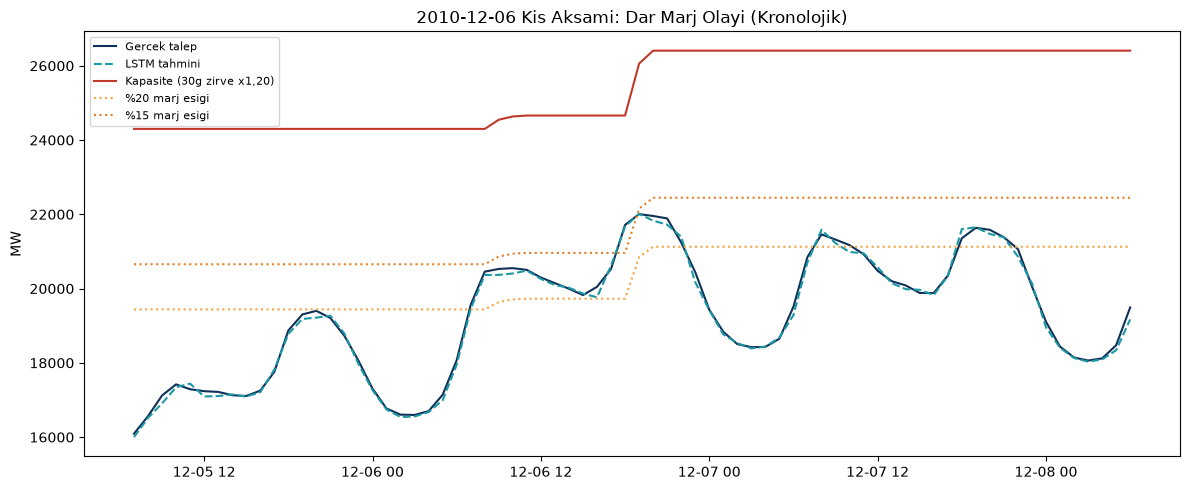

In [29]:
import matplotlib.pyplot as plt

center = df[df["Datetime"] == pd.Timestamp("2010-12-06 19:00:00")].index[0]
idxs = range(center - 36, center + 36)

windows = np.stack([hist_scaler.transform(df.iloc[i-24:i][features].values) for i in idxs])
preds = hist_model.predict(windows, verbose=0).flatten()
dummy = np.zeros((len(preds), len(features)))
dummy[:, 0] = preds
fc = hist_scaler.inverse_transform(dummy)[:, 0]

times = df.loc[list(idxs), "Datetime"]
actual = df.loc[list(idxs), "AEP_MW"]
cap = [df.iloc[i-24*30:i]["AEP_MW"].max() * 1.20 for i in idxs]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(times, actual, label="Gercek talep", color="#0F3057")
ax.plot(times, fc, label="LSTM tahmini", color="#1B98A4", linestyle="--")
ax.plot(times, cap, label="Kapasite (30g zirve x1,20)", color="#C0392B")
ax.plot(times, [c * 0.80 for c in cap], label="%20 marj esigi", color="#F2A541", linestyle=":")
ax.plot(times, [c * 0.85 for c in cap], label="%15 marj esigi", color="#E67E22", linestyle=":")
ax.set_ylabel("MW")
ax.set_title("2010-12-06 Kis Aksami: Dar Marj Olayi (Kronolojik)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(r"C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\graphs\viz_tight_margin_event_2010-12-06.png", dpi=150)
plt.show()

### Hücre 6: Seçilen anı n8n'e gönder (Hücre 4'ün çıktısına bakıp saati seçtikten sonra)

In [30]:
tarihi_senaryo("2009-12-10 18:00:00", send=True)

                 Datetime   AEP_MW
45507 2009-12-10 15:00:00  19190.0
45508 2009-12-10 16:00:00  19137.0
45509 2009-12-10 17:00:00  19757.0
45510 2009-12-10 18:00:00  21072.0
45511 2009-12-10 19:00:00  21601.0
45512 2009-12-10 20:00:00  21605.0
45513 2009-12-10 21:00:00  21567.0
Gercek: 21072 | Tahmin: 21062 | Kapasite: 23875 | Tahmin marji: %11.8 | Donem: peak
RAG sorgusu: grid capacity shortfall reserve activation peak
Agent karari: {'reasoning_steps': 'Forecasted demand of 21,062 MW against 23,875 MW available capacity leaves a reserve margin of approximately 13.4%, which falls below the standard 15-20% buffer during a critical peak period. Given the tight margin at peak hours with upper confidence reaching 21,638 MW, proactive monitoring and preparatory measures are warranted.', 'status': 'attention', 'decision': 'demand_response_alert', 'justification': 'Operating reserve margin is below the typical 15-20% threshold during the peak period; consistent with PJM procedures, a Maximum

Notebook'ta o an bellekte olan her önemli değişkeni (veri boyutu, model config, eğitim geçmişi, RMSPE'ler, saatlik hata, Faz 5'in gerçek örnek çalıştırması) tek bir run_summary.json'a yazıyor. Kernel kapansa bile bu dosya diskte kalıyor

In [31]:
import json
from datetime import datetime

summary = {
    "run_timestamp": datetime.now().isoformat(),
    "data": {
        "rows": int(df.shape[0]),
        "date_range": [str(df["Datetime"].min()), str(df["Datetime"].max())],
    },
    "model_config": {
        "window_size": window_size,
        "n_features": n_features,
        "features": features,
    },
    "training": {
        "epochs_run": len(history.history["loss"]),
        "final_train_loss": float(history.history["loss"][-1]),
        "final_val_loss": float(history.history["val_loss"][-1]),
        "best_val_loss": float(min(history.history["val_loss"])),
    },
    "metrics": {
        "baseline_rmspe": float(baseline_rmspe),
        "lstm_rmspe": float(lstm_rmspe),
        "improvement_factor": float(baseline_rmspe / lstm_rmspe),
        "valid_rows_for_rmspe": int(valid_mask.sum()),
    },
    "hourly_error": test_results.groupby("hour")["error_pct"].apply(
        lambda x: float(x.abs().mean())
    ).to_dict(),
    "end_to_end_example": {
        "demand_forecast": demand_forecast,
        "grid_status": grid_status,
        "agent_decision": decision_json,
    },
}

summary_path = r"C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\metrics\run_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Full run summary saved to:", summary_path)
print(json.dumps(summary, indent=2, ensure_ascii=False)[:2000])

Full run summary saved to: C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\metrics\run_summary.json
{
  "run_timestamp": "2026-09-28T14:55:18.925852",
  "data": {
    "rows": 121273,
    "date_range": [
      "2004-10-01 01:00:00",
      "2018-08-03 00:00:00"
    ]
  },
  "model_config": {
    "window_size": 24,
    "n_features": 9,
    "features": [
      "AEP_MW",
      "hour",
      "day_of_week",
      "month",
      "is_weekend",
      "is_holiday",
      "avg_temp_f",
      "HDD",
      "CDD"
    ]
  },
  "training": {
    "epochs_run": 20,
    "final_train_loss": 0.006444139871746302,
    "final_val_loss": 0.007018185220658779,
    "best_val_loss": 0.0059585790149867535
  },
  "metrics": {
    "baseline_rmspe": 0.0837647270056018,
    "lstm_rmspe": 0.027334567483591043,
    "improvement_factor": 3.06442481871666,
    "valid_rows_for_rmspe": 696
  },
  "hourly_error": {
    "0": 0.017167007936798626,
    "1": 0.020527187520749845,
    "2": 0.023946130254667602,
    "3": 0.02153722511

karar sınırlarını (decision boundaries) yakalayan senaryo bazlı test

In [32]:
import time
from datetime import datetime

# Gece yarisi zaten elimizde (onceki run_summary.json) - tekrar uretmiyoruz
scenario_offsets = {
    "example_yillik_zirve": 560
}

end_to_end_examples = {}
test_dates = df[df["Datetime"] > split_date]["Datetime"].reset_index(drop=True)

for label, offset in scenario_offsets.items():
    end_idx = len(test_scaled) - offset
    window = test_scaled[end_idx - window_size: end_idx]
    model_input = window.reshape(1, window_size, n_features)

    pred_scaled = model.predict(model_input, verbose=0).flatten()[0]
    dummy_row = np.zeros((1, n_features))
    dummy_row[0, 0] = pred_scaled
    ex_forecast_mw = scaler.inverse_transform(dummy_row)[0, 0]

    margin = ex_forecast_mw * lstm_rmspe
    ex_ci = [round(ex_forecast_mw - margin), round(ex_forecast_mw + margin)]

    actual_datetime = test_dates.iloc[end_idx - 1]
    hr = actual_datetime.hour
    ex_time_period = "day" if 7 <= hr < 18 else ("peak" if 18 <= hr < 23 else "night")

    ex_demand_forecast = {"region": "AEP", "forecast_mw": round(ex_forecast_mw), "confidence_interval": ex_ci}
    ex_grid_status = {
        "available_capacity_mw": available_capacity_mw,
        "time_period": ex_time_period,
        "capacity_source": "simulated_from_PJM_2027-2028_IRM_20pct",
    }

    ex_context = retrieve_context(f"grid capacity shortfall reserve activation {ex_time_period}")
    ex_content = f"""<demand_forecast>
{json.dumps(ex_demand_forecast)}
</demand_forecast>
<grid_status>
{json.dumps(ex_grid_status)}
</grid_status>
<official_procedure_context>
{ex_context}
</official_procedure_context>"""

    try:
        ex_result_text = get_agent_decision(ex_content, SYSTEM_PROMPT)
        ex_decision = json.loads(ex_result_text)
        end_to_end_examples[label] = {
            "actual_datetime": str(actual_datetime),
            "demand_forecast": ex_demand_forecast,
            "grid_status": ex_grid_status,
            "agent_decision": ex_decision,
        }
        print(f"{label} ({actual_datetime}): {ex_decision['decision']} ({ex_decision['status']}) - {round(ex_forecast_mw)} MW")
    except Exception as e:
        print(f"{label}: HATA - {e}")
    time.sleep(1)

# ONEMLI: onceki run_summary.json'un USTUNE YAZMIYORUZ - benzersiz, zaman
# damgali yeni bir dosya adi kullaniyoruz
run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
scenario_summary_path = rf"C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\metrics\run_summary_scenarios_{run_id}.json"

with open(scenario_summary_path, "w", encoding="utf-8") as f:
    json.dump({"end_to_end_examples": end_to_end_examples}, f, indent=2, ensure_ascii=False)

print("\nYeni senaryo dosyasi kaydedildi:", scenario_summary_path)
print("(Onceki run_summary.json'a HIC dokunulmadi)")

example_yillik_zirve (2018-07-10 16:00:00): normal_operation (normal) - 21576 MW

Yeni senaryo dosyasi kaydedildi: C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\metrics\run_summary_scenarios_20260928_145523.json
(Onceki run_summary.json'a HIC dokunulmadi)


### 2) EDA Hücresi — Gerçek "En Sıkışık" Anı Bulma

In [33]:
test_period = df[df["Datetime"] > split_date].reset_index(drop=True)

peak_idx = test_period["AEP_MW"].idxmax()
peak_row = test_period.loc[peak_idx]

teorik_marj = (available_capacity_mw - peak_row["AEP_MW"]) / available_capacity_mw * 100
offset_gerekli = len(test_period) - (peak_idx + 1)

print("EDA: Test doneminin en yuksek GERCEK talep ani")
print(f"  Tarih/Saat: {peak_row['Datetime']}")
print(f"  Gercek AEP_MW: {peak_row['AEP_MW']:.0f}")
print(f"  Simule kapasite: {available_capacity_mw}")
print(f"  Teorik marj: %{teorik_marj:.1f}")
print(f"\n  scenario_offsets'e eklenecek offset: {offset_gerekli}")
print(f"  Onerilen satir: \"example_yillik_zirve\": {offset_gerekli},")

EDA: Test doneminin en yuksek GERCEK talep ani
  Tarih/Saat: 2018-07-10 16:00:00
  Gercek AEP_MW: 21470
  Simule kapasite: 25570
  Teorik marj: %16.0

  scenario_offsets'e eklenecek offset: 560
  Onerilen satir: "example_yillik_zirve": 560,


### STRES TEST

In [34]:
# STRES TESTI: gercek zirve talebini kullanip, kapasiteyi BILINCLI OLARAK
# dusurerek "attention" bolgesini gozlemliyoruz. Bu GERCEK bir tarihsel
# an DEGIL - "capacity_source" alaninda acikca boyle etiketlenmistir.
stress_capacity = round(peak_row["AEP_MW"] / 0.90)  # ~%10 marj hedefleniyor

stress_demand_forecast = {"region": "AEP", "forecast_mw": round(peak_row["AEP_MW"]), "confidence_interval": [round(peak_row["AEP_MW"]*0.98), round(peak_row["AEP_MW"]*1.02)]}
stress_grid_status = {
    "available_capacity_mw": stress_capacity,
    "time_period": "day",
    "capacity_source": "STRESS_TEST_hypothetical_reduced_capacity",
}

stress_context = retrieve_context("grid capacity shortfall reserve activation attention")
stress_content = f"""<demand_forecast>
{json.dumps(stress_demand_forecast)}
</demand_forecast>
<grid_status>
{json.dumps(stress_grid_status)}
</grid_status>
<official_procedure_context>
{stress_context}
</official_procedure_context>"""

stress_result = json.loads(get_agent_decision(stress_content, SYSTEM_PROMPT))
print("Stres testi karari:", stress_result["decision"], "-", stress_result["status"])

all_examples_extra = {"example_STRES_TESTI_dusuk_kapasite": {
    "actual_datetime": str(peak_row["Datetime"]) + " (gercek tarih, kapasite hipotetik)",
    "demand_forecast": stress_demand_forecast,
    "grid_status": stress_grid_status,
    "agent_decision": stress_result,
}}
with open(rf"{metrics_dir}\run_summary_scenarios_stress_test.json", "w", encoding="utf-8") as f:
    json.dump({"end_to_end_examples": all_examples_extra}, f, indent=2, ensure_ascii=False)
print("Kaydedildi, grafik hucresini tekrar calistirin.")

Stres testi karari: demand_response_alert - attention
Kaydedildi, grafik hucresini tekrar calistirin.


### load_all_scenarios

In [35]:
import sys
sys.path.append(r"C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\notepads")
from scenario_comparison import load_all_scenarios

metrics_dir = r"C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\metrics"
comparison_table = load_all_scenarios(metrics_dir)

comparison_table.to_csv(r"C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\scenario_comparison_table.csv", index=False)

print(f"Toplam {len(comparison_table)} senaryo karsilastirildi:\n")
print(comparison_table.to_string(index=False))

Toplam 8 senaryo karsilastirildi:

                           senaryo                                             tarih_saat  tahmin_mw  kapasite_mw  marj_yuzde zaman_dilimi     durum                 karar belirsizlik
example_STRES_TESTI_dusuk_kapasite 2018-07-10 16:00:00 (gercek tarih, kapasite hipotetik)      21470        23856        10.0          day attention demand_response_alert         low
              example_yillik_zirve                                    2018-07-10 16:00:00      21576        25570        15.6          day    normal      normal_operation         low
              example_yillik_zirve                                    2018-07-10 16:00:00      21576        25570        15.6          day    normal      normal_operation         low
              example_yillik_zirve                                    2018-07-10 16:00:00      21576        25570        15.6          day    normal      normal_operation         low
                      example_peak                

### Görselleştirme

Kod kaydedildi: C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\graphs\generate_visualizations.py


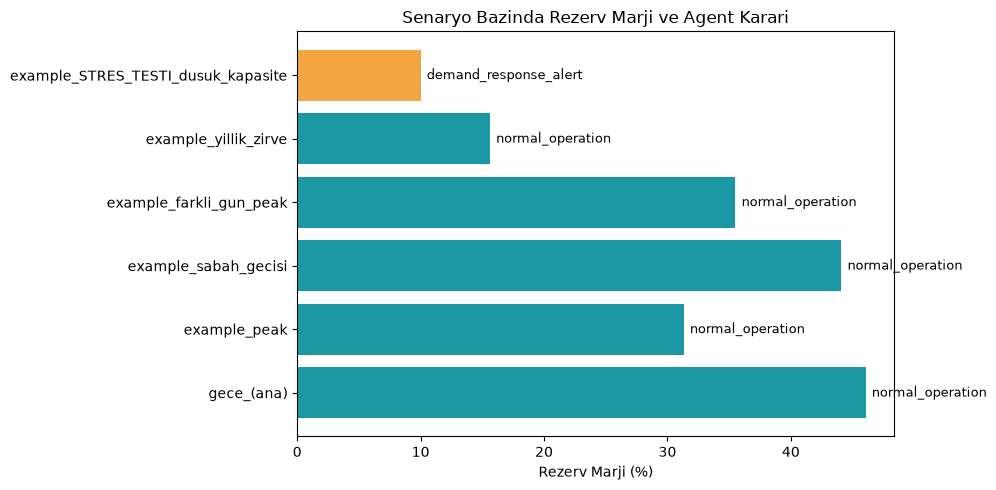

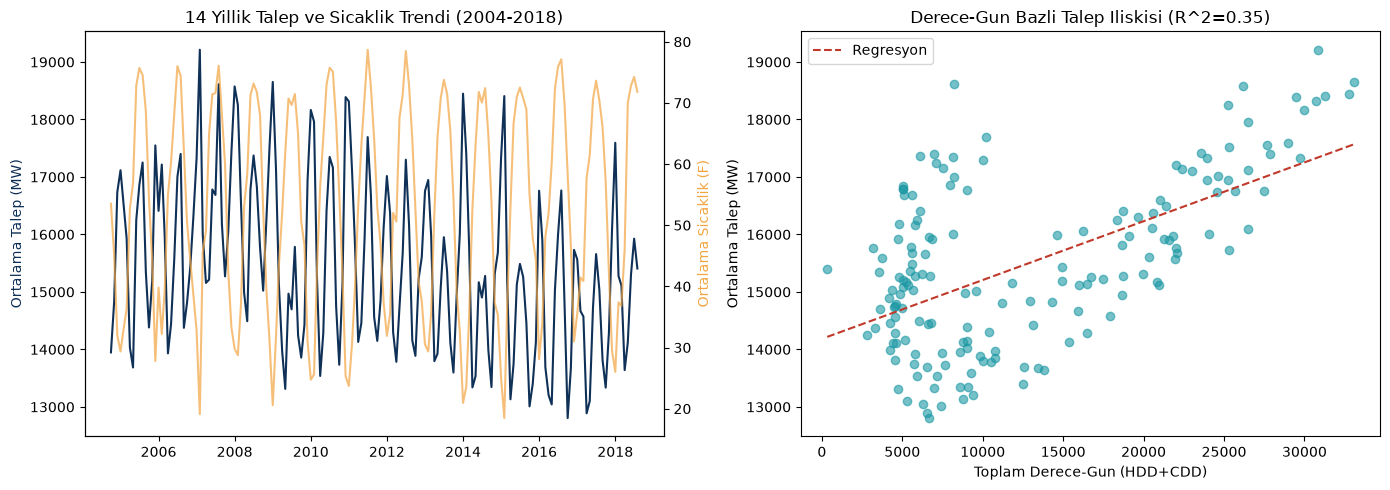


Grafikler kaydedildi: C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\graphs


In [36]:
import os, glob, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

graphs_dir = r"C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\graphs"
metrics_dir = r"C:\Deep_Learning_to_AI_Agents\Bitirme_Proje\metrics"
os.makedirs(graphs_dir, exist_ok=True)

# --- ONCE KODUN KENDISINI KAYDET ---
viz_code = '''# Bu dosya, ayni klasordeki PNG grafiklerini ureten koddur.
# 1.ipynb notebook'undan otomatik olarak kaydedilmistir.
import glob, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

metrics_dir = r"C:\\Deep_Learning_to_AI_Agents\\Bitirme_Proje\\metrics"
graphs_dir = r"C:\\Deep_Learning_to_AI_Agents\\Bitirme_Proje\\graphs"

all_examples = {}
try:
    with open(f"{metrics_dir}\\\\run_summary.json", encoding="utf-8") as f:
        main_data = json.load(f)
    if "end_to_end_example" in main_data:
        all_examples["gece_(ana)"] = main_data["end_to_end_example"]
    if "end_to_end_examples" in main_data:
        all_examples.update(main_data["end_to_end_examples"])
except FileNotFoundError:
    pass
for path in glob.glob(f"{metrics_dir}\\\\run_summary_scenarios_*.json"):
    with open(path, encoding="utf-8") as f:
        all_examples.update(json.load(f).get("end_to_end_examples", {}))

labels = list(all_examples.keys())
forecasts = [ex["demand_forecast"]["forecast_mw"] for ex in all_examples.values()]
capacities = [ex["grid_status"]["available_capacity_mw"] for ex in all_examples.values()]
decisions = [ex["agent_decision"]["decision"] for ex in all_examples.values()]

decision_colors = {"normal_operation": "#1B98A4", "demand_response_alert": "#F2A541", "activate_reserve": "#C0392B"}
colors = [decision_colors.get(d, "#999999") for d in decisions]
margin_pct = [(c - f) / c * 100 for f, c in zip(forecasts, capacities)]

fig, ax = plt.subplots(figsize=(10, 5))
y_pos = np.arange(len(labels))
ax.barh(y_pos, margin_pct, color=colors)
ax.set_yticks(y_pos); ax.set_yticklabels(labels)
ax.set_xlabel("Rezerv Marji (%)")
ax.set_title("Senaryo Bazinda Rezerv Marji ve Agent Karari")
for i, (m, d) in enumerate(zip(margin_pct, decisions)):
    ax.text(m + 0.5, i, d, va="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"{graphs_dir}\\\\viz_decision_map.png", dpi=150)
plt.close()

monthly = pd.read_csv(f"{metrics_dir}\\\\monthly_summary_full_period.csv")
monthly["year_month"] = pd.to_datetime(monthly["year_month"])
monthly["total_degree_days"] = monthly["total_hdd"] + monthly["total_cdd"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax1 = axes[0]
ax1.plot(monthly["year_month"], monthly["avg_mw"], color="#0F3057")
ax1.set_ylabel("Ortalama Talep (MW)", color="#0F3057")
ax2 = ax1.twinx()
ax2.plot(monthly["year_month"], monthly["avg_temp_f_mean"], color="#F2A541", alpha=0.7)
ax2.set_ylabel("Ortalama Sicaklik (F)", color="#F2A541")
ax1.set_title("14 Yillik Talep ve Sicaklik Trendi (2004-2018)")

ax3 = axes[1]
ax3.scatter(monthly["total_degree_days"], monthly["avg_mw"], color="#1B98A4", alpha=0.6)
z = np.polyfit(monthly["total_degree_days"], monthly["avg_mw"], 1)
trend_x = np.linspace(monthly["total_degree_days"].min(), monthly["total_degree_days"].max(), 50)
ax3.plot(trend_x, np.polyval(z, trend_x), color="#C0392B", linestyle="--", label="Regresyon")
r2 = np.corrcoef(monthly["total_degree_days"], monthly["avg_mw"])[0, 1] ** 2
ax3.set_xlabel("Toplam Derece-Gun (HDD+CDD)")
ax3.set_ylabel("Ortalama Talep (MW)")
ax3.set_title(f"Derece-Gun Bazli Talep Iliskisi (R^2={r2:.2f})")
ax3.legend()
plt.tight_layout()
plt.savefig(f"{graphs_dir}\\\\viz_monthly_degree_days.png", dpi=150)
plt.close()
'''

with open(f"{graphs_dir}\\generate_visualizations.py", "w", encoding="utf-8") as f:
    f.write(viz_code)
print("Kod kaydedildi:", f"{graphs_dir}\\generate_visualizations.py")

# --- SONRA GRAFIKLERI URET (ayni mantik, notebook icinde de goster) ---
exec(viz_code.replace("plt.close()", "plt.show()"))
print("\nGrafikler kaydedildi:", graphs_dir)